In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [42]:
from google.colab import files
uploaded = files.upload()

Saving OnlineRetail.csv to OnlineRetail (1).csv


In [ ]:
!pip install openpyxl

In [44]:
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


### Check Missing Values

In [ ]:
print(df.isna())

        InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  \
0           False      False        False     False        False      False   
1           False      False        False     False        False      False   
2           False      False        False     False        False      False   
3           False      False        False     False        False      False   
4           False      False        False     False        False      False   
...           ...        ...          ...       ...          ...        ...   
541904      False      False        False     False        False      False   
541905      False      False        False     False        False      False   
541906      False      False        False     False        False      False   
541907      False      False        False     False        False      False   
541908      False      False        False     False        False      False   

        CustomerID  Country  
0            False   

In [ ]:
print(df.isna().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


Check duplicate rows

In [ ]:
df.duplicated()[df.duplicated()==True]

,0
517,True
527,True
537,True
539,True
555,True
...,...
541675,True
541689,True
541692,True
541699,True


### No. of rows and columns

In [ ]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (541909, 8) 

number of rows:  541909
number of columns:  8


### Data type of columns

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [51]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,535187,535187,535187,535187.000000,535187,535187.000000,401604.000000,535187
unique,24446,3958,4223,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114,2301,2357,NaN,NaN,NaN,NaN,488846
mean,NaN,NaN,NaN,9.671593,2011-07-04 11:43:44.485273600,4.645242,15281.160818,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13939.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 15:38:00,2.080000,15145.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 08:20:00,4.130000,16784.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


### Data Cleaning

Data cleaning was done to make the dataset ready for analysis. Duplicate rows were removed, and missing values in important columns were handled by removing incomplete rows. The data types were corrected, and invalid values such as negative quantities and extreme values were removed to improve the quality of the data.

In [49]:

# 1. Remove duplicate rows
df = df.drop_duplicates()

# 2. Handle missing values (important columns only)
df = df.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice", "Country", "Description"])

# 3. Convert data types
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")

# 4. Remove invalid values and outliers
df_clean = df[
    (df["Quantity"] > 0) &          # remove returns (negative values)
    (df["Quantity"] < 1000) &       # remove extreme large values
    (df["UnitPrice"] > 0) &         # remove zero/invalid prices
    (df["UnitPrice"] < 1000)        # remove extreme prices
].copy()

# 5. Check shapes
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

# 6. Preview data
df.head()
df_clean.head()

Original shape: (535187, 8)
Cleaned shape: (524708, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [50]:
df_clean.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,524708,524708,524708,524708.000000,524708,524708.000000,392557.000000,524708
unique,19897,3919,4023,NaN,NaN,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1113,2250,2308,NaN,NaN,NaN,NaN,479840
mean,NaN,NaN,NaN,9.976602,2011-07-04 15:29:32.703332352,3.676071,15287.797354,NaN
min,NaN,NaN,NaN,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 12:13:00,1.250000,13955.000000,NaN
50%,NaN,NaN,NaN,4.000000,2011-07-20 11:22:00,2.080000,15150.000000,NaN
75%,NaN,NaN,NaN,11.000000,2011-10-19 11:41:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,992.000000,2011-12-09 12:50:00,988.000000,18287.000000,NaN


# Distribution of Quantity

This chart shows the distribution of quantities purchased. Most transactions involve small quantities, while large quantities are less common.

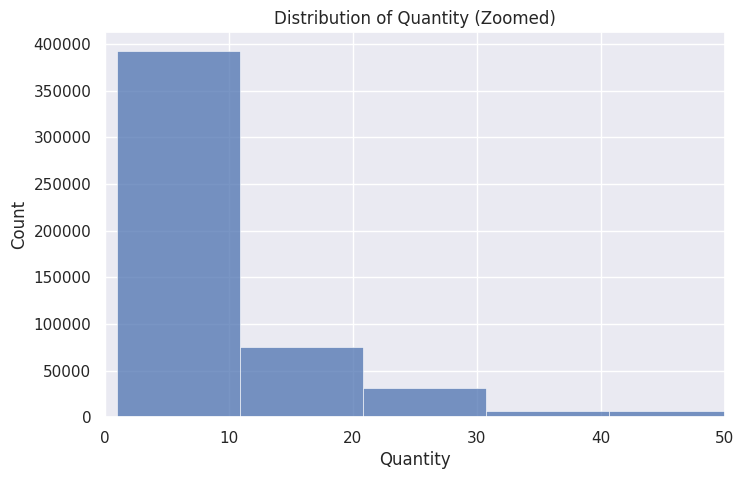

In [52]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["Quantity"], bins=100)
plt.xlim(0, 50)
plt.title("Distribution of Quantity (Zoomed)")
plt.show()

# Total Quantity by Country

This bar chart shows the total quantity of products purchased by each country. It helps identify which countries contribute the most to sales.

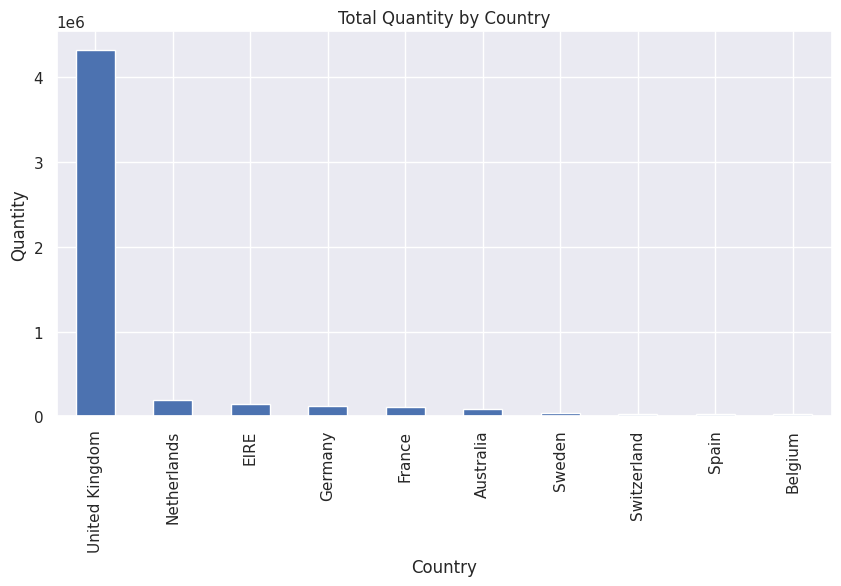

In [53]:
country_quantity = df_clean.groupby("Country")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_quantity.head(10).plot(kind="bar")

plt.title("Total Quantity by Country")
plt.ylabel("Quantity")
plt.show()

This bar chart shows the total quantity by country after removing the United Kingdom. The UK was excluded because it had significantly higher values, which made it difficult to clearly compare the other countries.

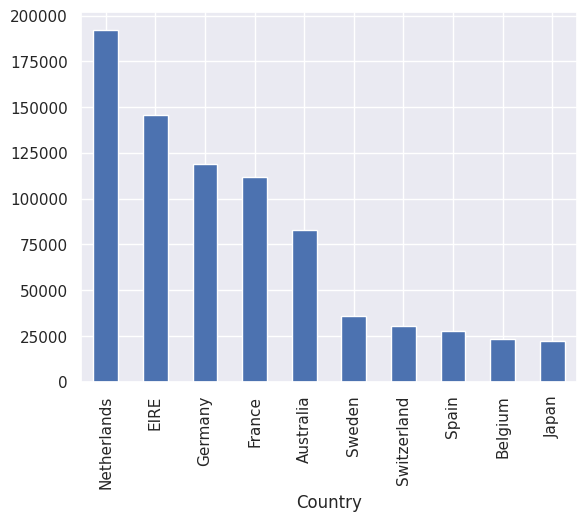

,Quantity
Country,
Netherlands,192153
EIRE,145563
Germany,119154
France,112057
Australia,82739
Sweden,36078
Switzerland,30617
Spain,27933
Belgium,23237


In [55]:
df_no_uk = df_clean[df_clean["Country"] != "United Kingdom"]

country_quantity = df_no_uk.groupby("Country")["Quantity"].sum().sort_values(ascending=False)

country_quantity.head(10).plot(kind="bar")
plt.show()
country_quantity

In [56]:
country_quantity = df_clean.groupby("Country")["Quantity"].sum().sort_values(ascending=False)

country_quantity.head(10)

,Quantity
Country,
United Kingdom,4323633
Netherlands,192153
EIRE,145563
Germany,119154
France,112057
Australia,82739
Sweden,36078
Switzerland,30617
Spain,27933


# Relationship between Quantity and Unit Price

This scatter plot shows the relationship between quantity and unit price. Most purchases occur at low quantities and prices, and there is no strong relationship between the two variables.

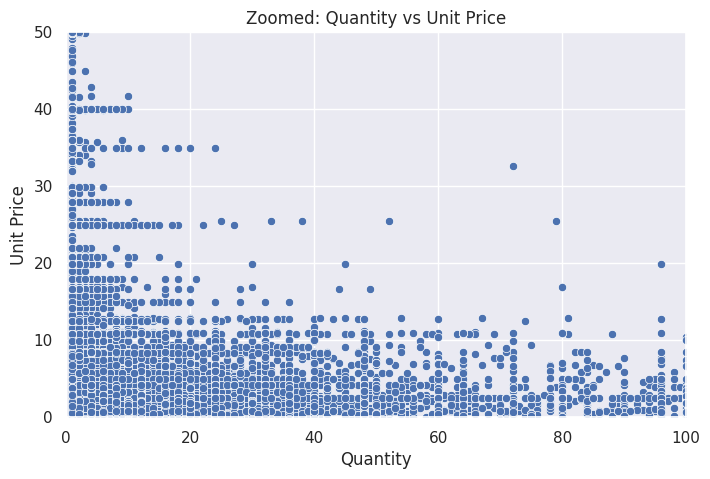

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df_clean["Quantity"], y=df_clean["UnitPrice"])

plt.xlim(0, 100)
plt.ylim(0, 50)
plt.title(" Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")

plt.show()

# Correlation between Variables

This heatmap shows the correlation between quantity and unit price. The correlation value is approximately -0.001, which indicates a very weak relationship between the two variables. This means that changes in quantity do not significantly affect the unit price.

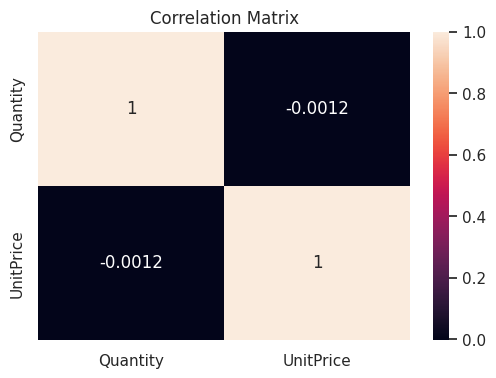

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(df[["Quantity", "UnitPrice"]].corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

## Time-Based Analysis


Monthly Quantity Trend
This line chart shows how the total quantity changes over time. It helps identify trends and variations in sales across different months. The highest sales were recorded in November, while the lowest sales occurred in February, indicating seasonal fluctuations in customer demand.

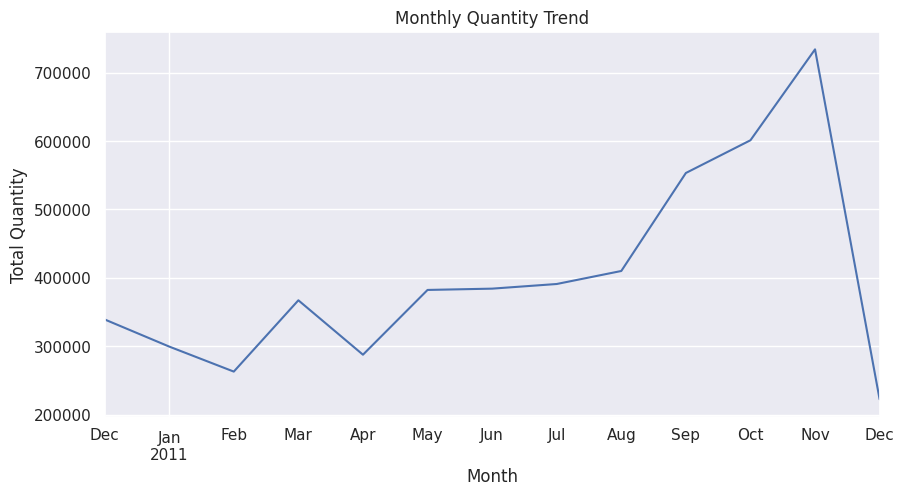

In [57]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_quantity = df_clean.groupby("Month")["Quantity"].sum()

plt.figure(figsize=(10,5))
monthly_quantity.plot()

plt.title("Monthly Quantity Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.show()

# Top 10 Products by **Quantity** **bold text**

This bar chart shows the top 10 products based on total quantity sold. It helps identify the most popular products in the dataset. The product "JUMBO BAG RED RETROSPOT" has the highest quantity sold, while "BROCADE RING PURSE" has the lowest among the top 10 products.

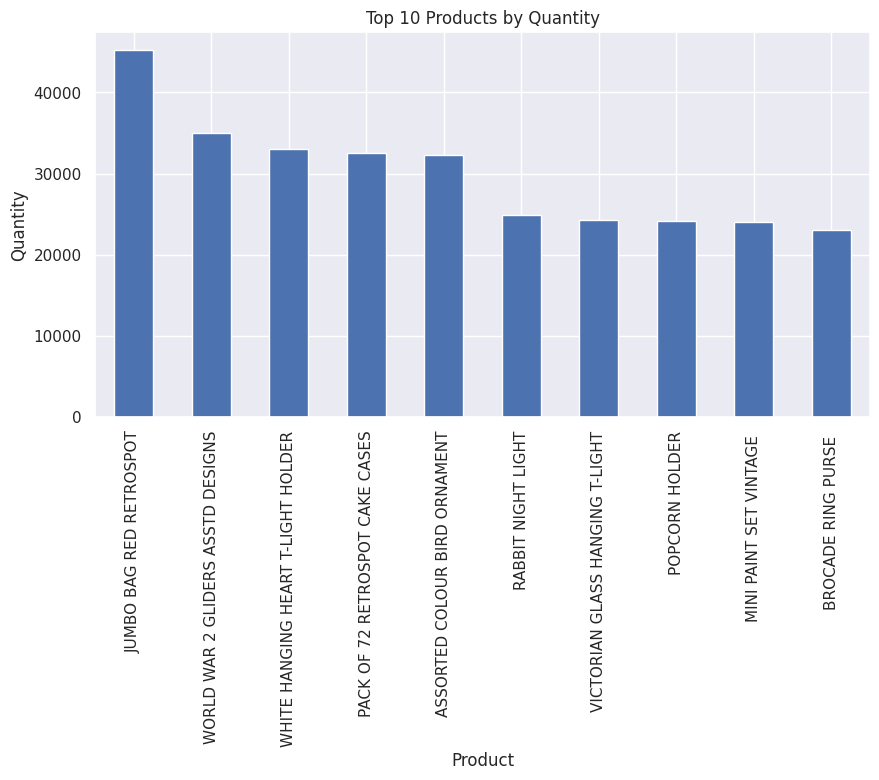

In [58]:
product_quantity = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_quantity.head(10).plot(kind="bar")

plt.title("Top 10 Products by Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()